In [27]:
pip install pgmpy==0.1.21

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.6 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [15]:
from mimetypes import init
import numpy as np

weathers = ['S', 'R', 'C']

transition_matrix = np.array([
    [0.33, 0.33, 0.34],  # S -> S, R, C
    [0.33, 0.33, 0.34],  # R -> S, R, C
    [0.33, 0.33, 0.34]   # C -> S, R, C
])

def simulate_weather_prob(init_weather, days):
    current_weather = init_weather
    weather_sequence = [current_weather]
    prob = 0
    rainy_count = 1 if current_weather == 'R' else 0

    for i in range(days):
        if current_weather == 'S':
            next_weath = np.random.choice(weathers, p=transition_matrix[0])
        elif current_weather == 'R':
            next_weath = np.random.choice(weathers, p=transition_matrix[1])
        elif current_weather == 'C':
            next_weath = np.random.choice(weathers, p=transition_matrix[2])
        else:
            print("Invalid weather input")
            return

        # Track consecutive rainy days
        if next_weath == 'R':
            rainy_count += 1
        else:
            rainy_count = 0

        weather_sequence.append(str(next_weath))
        current_weather = next_weath

        if rainy_count%3 == 0 and rainy_count >=3:
            prob = (rainy_count/3)/days
            print("prob: ",prob)
            break
            
    if prob == 0 :
        print("no consective rainy days")
    return weather_sequence



init_weather = 'R'
days = 10
weather_seq = simulate_weather_prob(init_weather, days)
print(weather_seq)


prob:  0.1
['R', 'C', 'C', 'R', 'R', 'R']


In [32]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

model = DiscreteBayesianNetwork([
    ('Disease', 'Fever'),
    ('Disease', 'Chills'),
    ('Disease', 'Fatigue'),
    ('Disease', 'Cough')
])

# Disease
cpd_Disease = TabularCPD(
    variable='Disease',
    variable_card=2,
    values=[[0.3], [0.7]]
)

# Fever
cpd_Fever = TabularCPD(
    variable='Fever',
    variable_card=2,
    values=[[0.1, 0.5], [0.9, 0.5]],
    evidence=['Disease'],
    evidence_card=[2]
)

# Fatigue
cpd_Fatigue = TabularCPD(
    variable='Fatigue',
    variable_card=2,
    values=[[0.3, 0.7], [0.7, 0.3]],
    evidence=['Disease'],
    evidence_card=[2]
)

# Cough
cpd_Cough = TabularCPD(
    variable='Cough',
    variable_card=2,
    values=[[0.2, 0.4], [0.8, 0.6]],
    evidence=['Disease'],
    evidence_card=[2]
)

# Chills
cpd_Chills = TabularCPD(
    variable='Chills',
    variable_card=2,
    values=[[0.4, 0.6], [0.6, 0.4]],
    evidence=['Disease'],
    evidence_card=[2]
)

model.add_cpds(cpd_Disease, cpd_Fever, cpd_Fatigue, cpd_Cough, cpd_Chills)

assert model.check_model()

inference = VariableElimination(model)

result1 = inference.query(
    variables=['Disease'],
    evidence={'Fever': 1, 'Cough': 1}
)

print(result1)

ImportError: cannot import name 'SHOW_PROGRESS' from 'pgmpy.global_vars' (/Users/hashirali/Library/Python/3.9/lib/python/site-packages/pgmpy/global_vars.py)

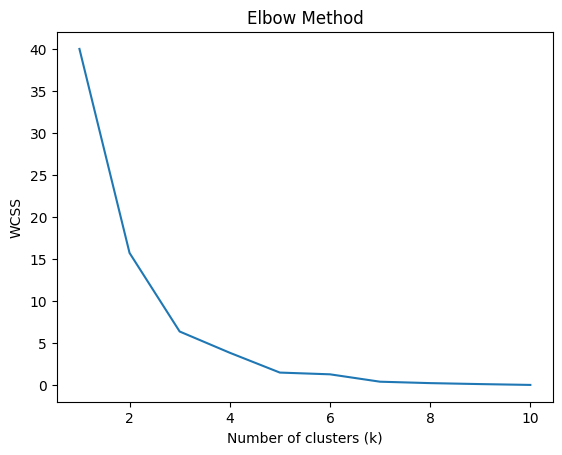

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost  \
0                  5   150000               15              5000   
1                  3   120000               18              4000   
2                  8   250000               10              7000   
3                  2    80000               22              2000   
4                  4   100000               20              3000   
5                  7   220000               12              6500   
6                  6   180000               16              5500   
7                 10   300000                8              8000   
8                  1    75000               24              1500   
9                  9   280000                9              7500   

   vehicle_type  Cluster  
0             0        2  
1             1        2  
2             2        1  
3             3        0  
4             1        2  
5             2        1  
6             0        2  
7             2        1  
8       

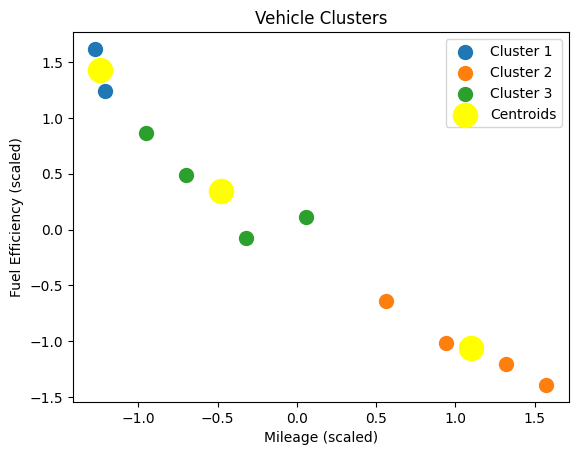

In [25]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# DATA
# -----------------------------
data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)

# -----------------------------
# PREPROCESSING
# -----------------------------

# Encode categorical column
mapping = {'SUV': 0, 'Sedan': 1, 'Truck': 2, 'Hatchback': 3}
df['vehicle_type'] = df['vehicle_type'].map(mapping)

# Select features (exclude serial number)
X = df[['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# ELBOW METHOD
# -----------------------------
wcss_list = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss_list.append(kmeans.inertia_)

# Plot elbow graph
plt.plot(range(1, 11), wcss_list)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

# -----------------------------
# APPLY K-MEANS (choose k from elbow, e.g., 3)
# -----------------------------
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_predict = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = y_predict

print(df)

# -----------------------------
# VISUALIZATION (2D projection)
# -----------------------------
# Using first 2 features for visualization
for i in range(kmeans.n_clusters):
    plt.scatter(X_scaled[y_predict == i, 0],
                X_scaled[y_predict == i, 1],
                s=100,
                label=f'Cluster {i+1}')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300,
            c='yellow',
            label='Centroids')

plt.title('Vehicle Clusters')
plt.xlabel('Mileage (scaled)')
plt.ylabel('Fuel Efficiency (scaled)')
plt.legend()
plt.show()